In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

import random

from SQUIC_functions import *

In [2]:
DATASET = "../datasets/AMLSimData/2_10K"

accounts = pd.read_csv(f'{DATASET}/accounts.csv')
transactions = pd.read_csv(f'{DATASET}/transactions.csv')

In [3]:
# Create root
balances = {}

# Take users data from account.csv
for _, row in accounts.iterrows():
    acc_id = row["ACCOUNT_ID"] # User id
    open_date = 0
    initial_balance = round(float(row["INIT_BALANCE"]), 2)

    balances[acc_id] = [{"date": open_date,
                         "balance": initial_balance
                        }]

In [4]:
# Apply transactions to users' balances
transactions.sort_values(by="TX_ID")

# Track the last balance for each account
current_balances = {acct_id: balances[acct_id][0]["balance"] for acct_id in balances}

for i, (_, row) in enumerate(transactions.iterrows()):
    orig_acct = row["SENDER_ACCOUNT_ID"]
    bene_acct = row["RECEIVER_ACCOUNT_ID"]
    amount = row["TX_AMOUNT"]
    tx_type = row['TX_TYPE']
    date = row["TIMESTAMP"]
    if orig_acct in balances: # check that sender has a deposit
        last_balance = balances[orig_acct][-1]["balance"] # read balance from balances
        if tx_type in ['TRANSFER', 'WITHDRAWAL']: # all TRANSFER in the csv
            new_balance = last_balance - amount
        # elif tx_type == 'DEPOSIT':
        #    new_balance = last_balance + amount

        balances[orig_acct].append({"date": date, "balance": round(new_balance, 2)})
    
    if bene_acct in balances: # check that receiver has a deposit
        last_balance = balances[bene_acct][-1]["balance"]
        if tx_type in ['TRANSFER', 'DEPOSIT']:
            new_balance = last_balance + amount
        # elif tx_type == 'WITHDRAWAL':
        #     new_balance = last_balance - amount

        balances[bene_acct].append({"date": date, "balance": round(new_balance, 2)})

In [5]:
print(len(balances))

10000


In [6]:
import os
import json

file_path = "../datasets/json/10K.json"

# Otherwise, process your raw dataset and save
with open(file_path, "w") as f:
        json.dump(balances, f)

In [5]:
result = []

for date in sorted(set(transactions["TIMESTAMP"])):
    daily_balances = {
        "date": date,
        "balances": {
            str(user): {
                "balance": next((entry["balance"] for entry in reversed(b) if entry["date"] <= date), b[0]["balance"])
            } for user, b in balances.items()}
    }
    result.append(daily_balances)

In [ ]:
df = pd.DataFrame(result)

# Unpack 'balances' into separate columns for each user
df = df.join(pd.DataFrame(df['balances'].tolist()))

df.drop('balances', axis=1, inplace=True)
df.set_index('date', inplace=True)
df.drop('_id', axis=1, inplace=True, errors='ignore')

for col in df.columns:
    df[col] = df[col].apply(lambda x: x['balance'] if isinstance(x, dict) else x)

In [8]:
df

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.8,142.06,125.89,151.13,140.49,178.38,130.33,147.66,158.34,...,1.146210e+03,7.903200e+02,2.770150e+03,3.074230e+03,3.122300e+03,7.710300e+02,8.160900e+02,1.113220e+03,2.505310e+03,1.361130e+03
1,184.44,175.8,142.06,125.89,151.13,140.49,369.57,0.01,147.66,158.34,...,2.244260e+03,-1.484520e+03,5.821460e+03,6.989780e+03,6.556470e+03,9.088400e+02,1.579460e+03,2.093740e+03,4.695210e+03,3.082930e+03
2,184.44,175.8,142.06,125.89,151.13,148.74,369.57,0.01,147.66,158.34,...,2.627990e+03,9.538000e+01,7.941430e+03,1.276509e+04,1.000653e+04,2.264190e+03,2.739510e+03,2.767220e+03,7.006600e+03,4.094660e+03
3,184.44,175.8,142.06,125.89,151.13,148.74,369.57,0.01,147.66,158.34,...,2.773680e+03,1.811320e+03,1.193886e+04,1.985444e+04,1.449974e+04,3.341060e+03,3.673850e+03,3.145260e+03,9.319790e+03,5.740210e+03
4,184.44,175.8,142.06,125.89,151.13,148.74,369.57,0.01,147.66,0.02,...,3.753940e+03,4.622490e+03,1.403018e+04,2.427739e+04,1.857337e+04,4.321930e+03,4.249540e+03,3.675470e+03,1.114373e+04,6.627840e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,184.44,-3691.8,-2272.79,-1826.46,-3324.86,-2371.88,612.96,590.66,-3248.52,9476994.02,...,1.744558e+08,1.858088e+08,1.807265e+08,2.385128e+08,1.876246e+08,2.425374e+08,4.258409e+08,3.369211e+08,4.133597e+08,3.522696e+08
196,184.44,-3691.8,-2272.79,-1826.46,-3324.86,-2371.88,612.96,590.66,-3248.52,9476994.02,...,1.925790e+08,1.858104e+08,1.807289e+08,2.385184e+08,1.876290e+08,2.818782e+08,4.258418e+08,3.369215e+08,4.133576e+08,3.522715e+08
197,184.44,-3691.8,-2414.84,-1952.34,-3324.86,-2371.88,612.96,590.66,-3248.52,9476994.02,...,1.925814e+08,1.858109e+08,1.924960e+08,2.599992e+08,1.876324e+08,2.818789e+08,4.463646e+08,3.369225e+08,4.133600e+08,3.522725e+08


In [9]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in df.columns:
    plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
# plt.title("Balance Evolution of Users Over Time")
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
#plt.xticks(rotation=45)
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Add legend to differentiate users
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

date
0      184.44
1      184.44
2      184.44
3      184.44
4      184.44
        ...  
195    184.44
196    184.44
197    184.44
198    184.44
199    184.44
Name: 0, Length: 200, dtype: float64

# Balance Distribution

### First and last day

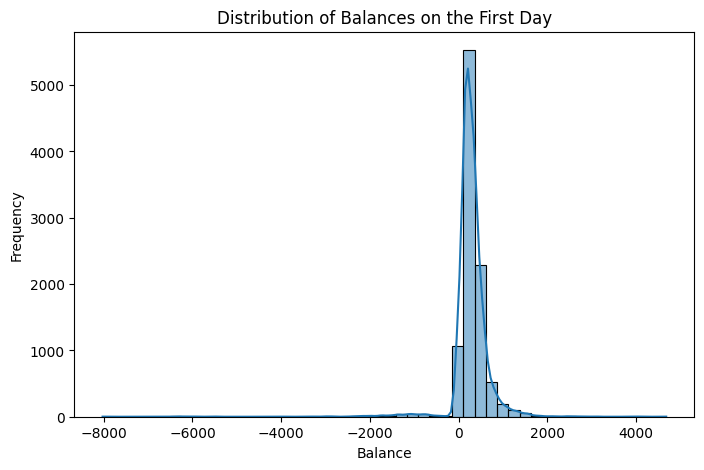

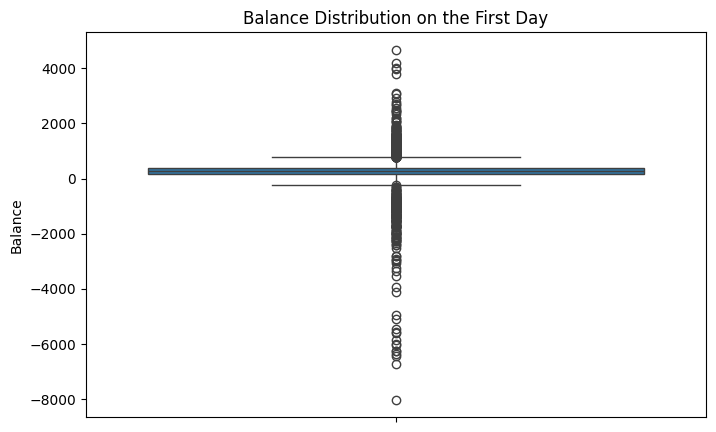

In [11]:
# Select the balances on the first day
first_day_balances = df.iloc[0]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(first_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the First Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=first_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the First Day")
plt.show()

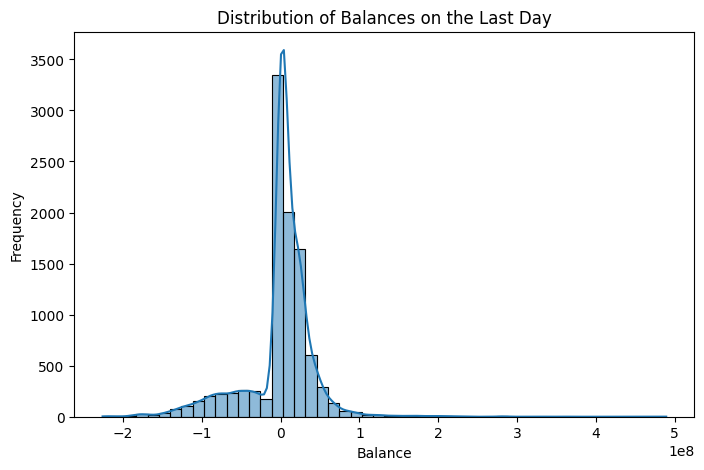

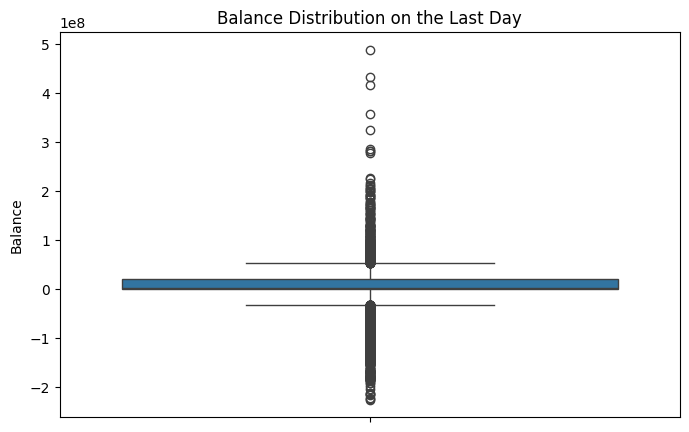

In [12]:
# Select the balances on the first day
last_day_balances = df.iloc[-1]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(last_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the Last Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=last_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the Last Day")
plt.show()

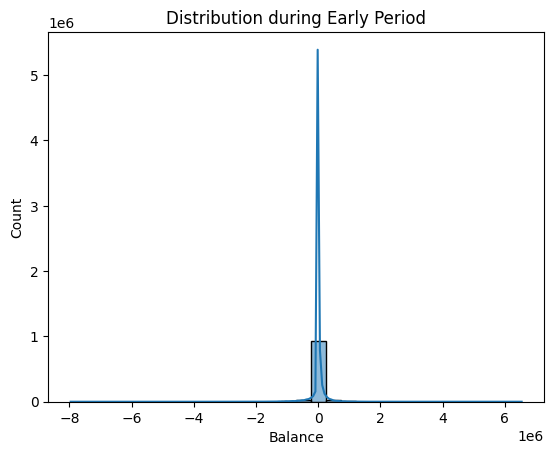

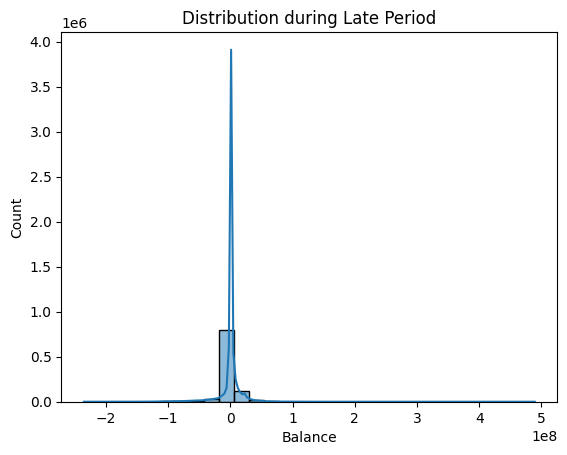

In [13]:
# Split the DataFrame into two parts
early_period = df.iloc[:int(0.5 * len(df))]
late_period  = df.iloc[int(0.5 * len(df)):]

# Plot distribution for early days (aggregated over users and days)
sns.histplot(early_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Early Period")
plt.xlabel("Balance")
plt.show()

# Plot distribution for late days
sns.histplot(late_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Late Period")
plt.xlabel("Balance")
plt.show()

### Total Distribution

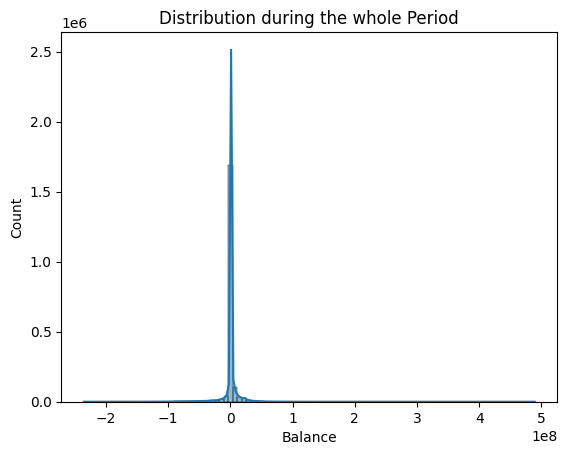

In [14]:
values_df = df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

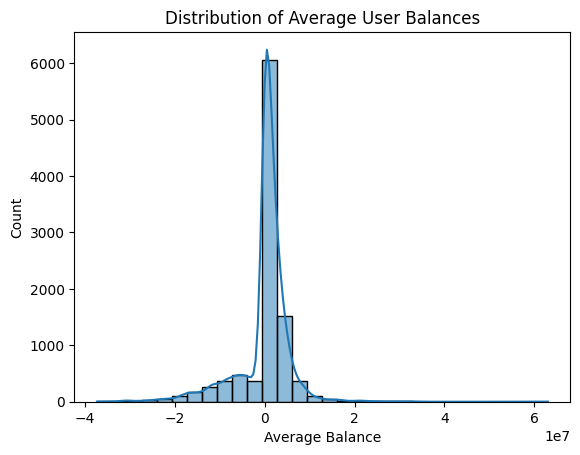

In [15]:
# Compute the mean balance per user over all days
user_means = df.mean(axis=0)

sns.histplot(user_means, bins=30, kde=True)
plt.title("Distribution of Average User Balances")
plt.xlabel("Average Balance")
plt.show()

# Techniques

## CLT

In [16]:
random_users = []

total_account = len(df.columns)

print(f"Total accounts: {total_account}")
random.seed(45)  # Fixes randomness for consistent results

for _ in range(9000):
    new = False
    while new == False:
        user = random.randint(0, total_account - 1)
        if user not in random_users:
            new = True
            random_users.append(user)

print(f"Number of extracted random accounts: {len(random_users)}")

Total accounts: 10000
Number of extracted random accounts: 9000


In [17]:
days = len(balances) # num of days
weeks = len(balances)//7 # num of weeks
rest = len(balances)%7 # remaining days

In [18]:
clt_distribution = []

# in order to appy CLT -> every week take the mean of the selected users' balances
for i in range(weeks):
    week_data = []
    week_balances = df.iloc[i*7]
    # print(week_balances.name)

    for user in random_users:
    # for user in range(len(df.columns)): -> se prendo tutti gli utenti
        # print(user)
        # print(week_balances[user])
        week_data.append(week_balances[user])
    
    mean = np.mean(week_data)
    clt_distribution.append(round(mean, 2))

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_6733/536784648.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  week_data.append(week_balances[user])


In [19]:
clt_distribution = [float(np_float) for np_float in clt_distribution]
clt_distribution

[280.27,
 272.84,
 268.49,
 227.42,
 232.65,
 196.76,
 136.87,
 62.07,
 110.08,
 4.82,
 -54.18,
 -101.28,
 485.53,
 399.4,
 -150.28,
 336.15,
 2697.55,
 4720.42,
 4812.52,
 8297.93,
 15747.65,
 18211.33,
 15643.41,
 20699.65,
 43678.12,
 41075.42,
 17326.47,
 -9807.08]

<function matplotlib.pyplot.show(close=None, block=None)>

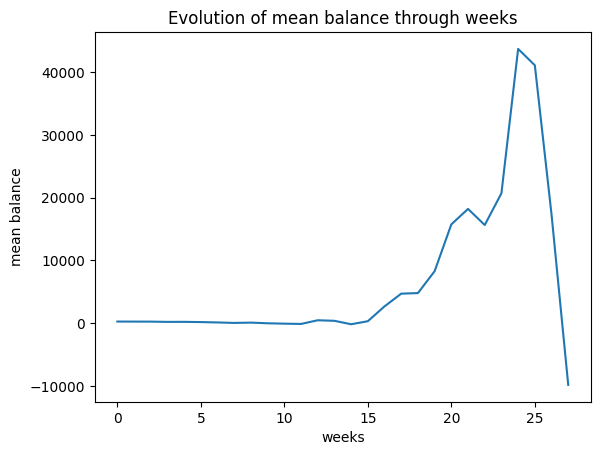

In [20]:
plt.plot(range(weeks), clt_distribution)
plt.xlabel("weeks")
plt.ylabel("mean balance")
plt.title("Evolution of mean balance through weeks")
plt.show

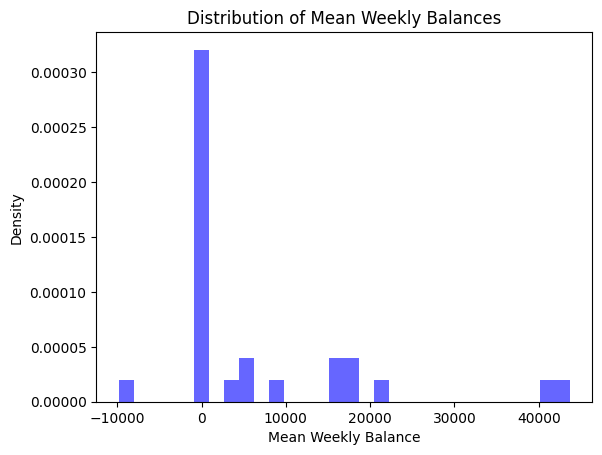

In [21]:
# Histogram to visually inspect the shape of the distribution of the mean balance during weeks
# X axis -> offset +7.469e4 from 74.690 to 74.696
plt.hist(clt_distribution, bins=30, density=True, alpha=0.6, color='b')
plt.xlabel("Mean Weekly Balance")
plt.ylabel("Density")
plt.title("Distribution of Mean Weekly Balances")
plt.show()

In [22]:
# If p > 0.05, the data is likely normally distributed
# If stat -> 1 the data is likely normally distributed
def ks_test(distribution):
    mu = np.mean(distribution)
    std = np.std(distribution)
    ks_stat, ks_p = stats.kstest(distribution, 'norm', args=(mu, std))

    print(f"K-S Test: Statistic={ks_stat:.4f}, p-value={ks_p:.4g}")

    if ks_p < 0.05:
        print("Data is likely NOT normal.")
    else:
        print("Data is likely normal.")

In [23]:
ks_test(clt_distribution)


K-S Test: Statistic=0.3008, p-value=0.009624
Data is likely NOT normal.


In [24]:
clt_mean = np.mean(clt_distribution)
clt_std = np.std(clt_distribution)

# Generate synthetic data using the CLT mean & std
clt_synthetic_data = np.random.normal(loc=clt_mean, scale=clt_std, size=(days, total_account))

# Convert to DataFrame
df_clt = pd.DataFrame(clt_synthetic_data)

In [25]:
values_df_clt = df_clt.values.flatten()

ks_test(values_df_clt)

K-S Test: Statistic=0.0004, p-value=0.8377
Data is likely normal.


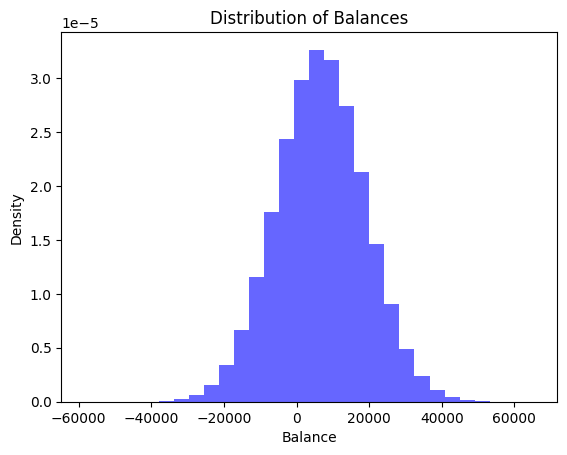

In [26]:
plt.hist(values_df_clt, bins=30, density=True, alpha=0.6, color='b')
plt.xlabel("Balance")
plt.ylabel("Density")
plt.title("Distribution of Balances")
plt.show()

## Log -> negative numbers

In [27]:
df_log = np.log(df + 1e9) # to avoid negative numbers
# df_log = np.log(df)

In [28]:
# Flatten the DataFrame values into a single array
values_df_log = df_log.values.flatten()

nan_count = np.isnan(values_df_log).sum()
print("Number of NaN values:", nan_count)

Number of NaN values: 0


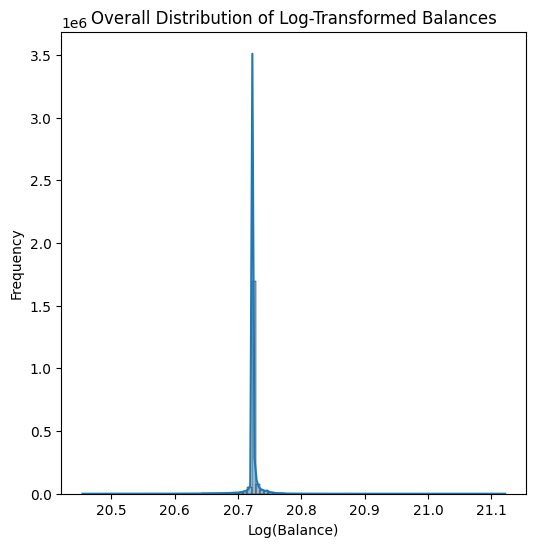

In [29]:
plt.figure(figsize=(6, 6))
sns.histplot(values_df_log, kde=True, bins=100, edgecolor='black')
plt.title("Overall Distribution of Log-Transformed Balances")
plt.xlabel("Log(Balance)")
plt.ylabel("Frequency")
plt.show()

Can't be computed due to negative numbers

In [30]:
ks_test(values_df_log)

K-S Test: Statistic=0.3925, p-value=0
Data is likely NOT normal.


## Wold

In [31]:
# Difference with previous row
df_w = df.diff().dropna()  # drop the first row which will be NaN

values_df_w = df_w.values.flatten()

# Remove NaN values (from the first differencing step)
values_df_w = values_df_w[~np.isnan(values_df_w)]

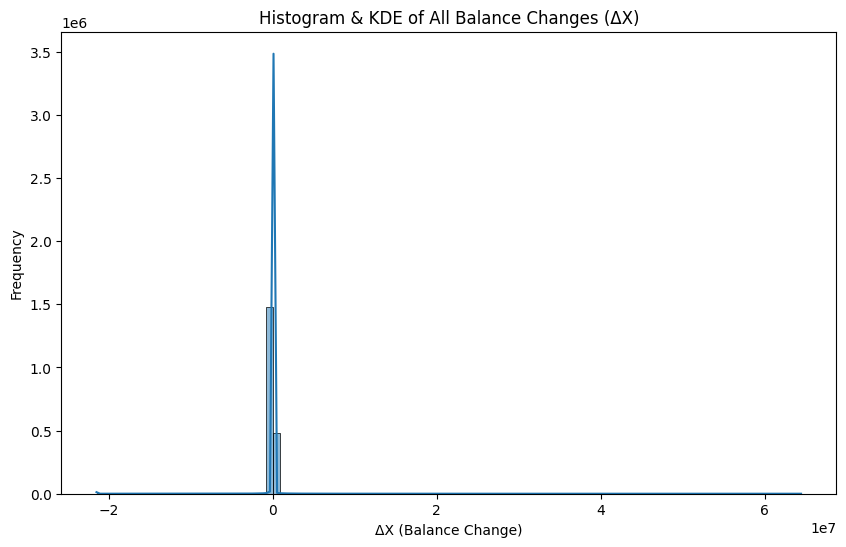

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(values_df_w, kde=True, bins=100, edgecolor='black')
plt.title("Histogram & KDE of All Balance Changes (ΔX)")
plt.xlabel("ΔX (Balance Change)")
plt.ylabel("Frequency")
plt.show()

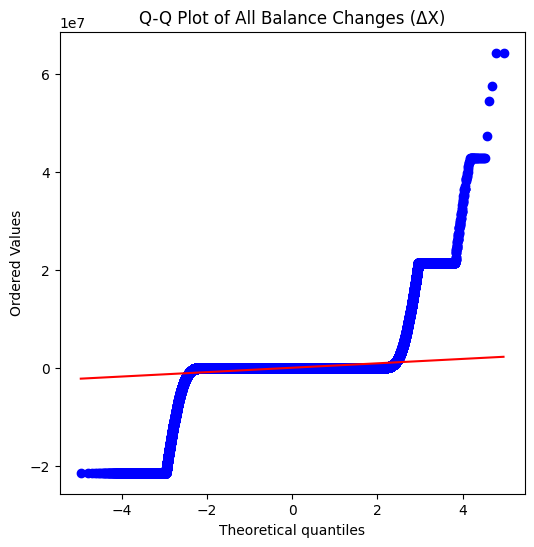

In [33]:
plt.figure(figsize=(6, 6))
stats.probplot(values_df_w, dist="norm", plot=plt)
plt.title("Q-Q Plot of All Balance Changes (ΔX)")
plt.show()

In [34]:
ks_test(values_df_w)

K-S Test: Statistic=0.4809, p-value=0
Data is likely NOT normal.


## Geometric brownian -> negative numbers

In [35]:
df_gmb = np.log((df / df.shift(1)) + 1e9) # Compute r_t = log(X_t / X_{t-1}) for each user
df_gmb = df_gmb.dropna()  # Remove the first row which will be NaN

# Flatten the DataFrame into a 1D array
values_df_gmb = df_gmb.values.flatten()

# Remove any potential NaN values
values_df_gmb = values_df_gmb[~np.isnan(values_df_gmb)]

/opt/anaconda3/envs/bank/lib/python3.9/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


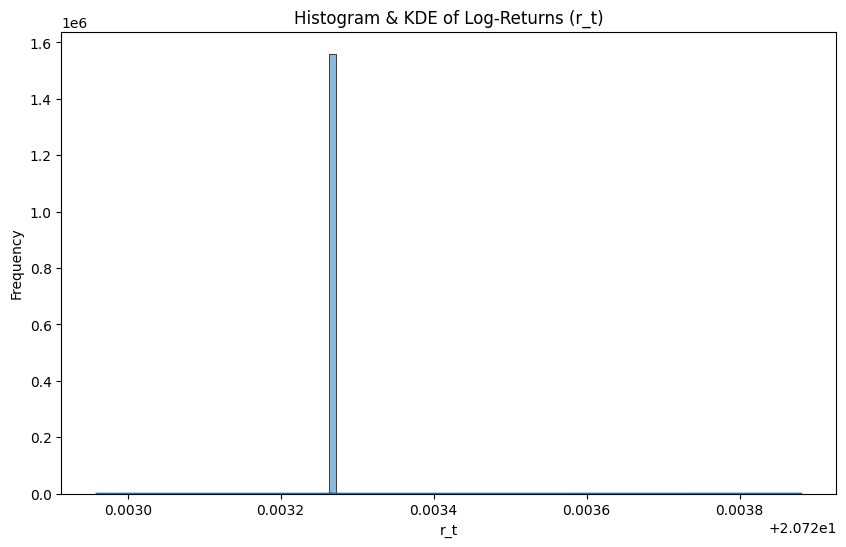

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(values_df_gmb, kde=True, bins=100, edgecolor='black')
plt.title("Histogram & KDE of Log-Returns (r_t)")
plt.xlabel("r_t")
plt.ylabel("Frequency")
plt.show()

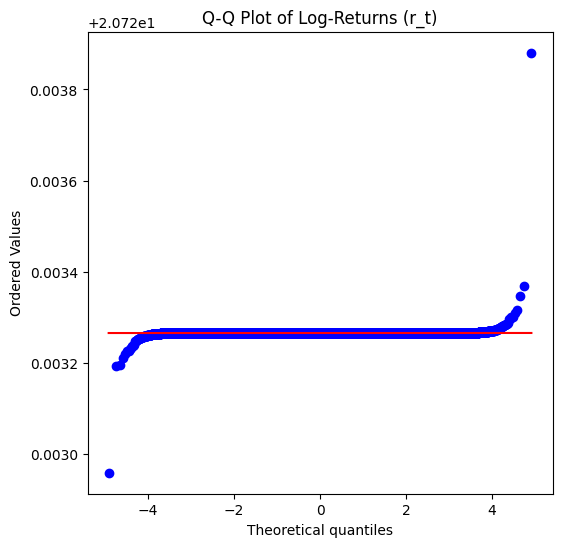

In [37]:
plt.figure(figsize=(6, 6))
stats.probplot(values_df_gmb, dist="norm", plot=plt)
plt.title("Q-Q Plot of Log-Returns (r_t)")
plt.show()

In [38]:
ks_test(values_df_gmb)

K-S Test: Statistic=0.4949, p-value=0
Data is likely NOT normal.


# Squic

In [39]:
def compute_squic(df, l):
    Y = df.T.to_numpy()  # Transpose to get shape (users, days)

    [X,_,_,_,_,_] = squic.run(Y,l)

    print(X.todense())
    return X

def count_zero(X):
    # Count nonzero elements in X
    num_nonzero = X.nnz

    # Compute sparsity level
    total_elements = X.shape[0] * X.shape[1]
    sparsity = num_nonzero / total_elements

    print(f"Number of nonzero elements: {num_nonzero}")
    print(f"Sparsity level: {sparsity:.4f}")

def nnz(X):
    # Count nonzero elements in X
    return X.nnz

def sparsity_pattern(X):
    plt.figure(figsize=(10, 10))
    plt.spy(X, markersize=5)  # Adjust markersize for better visibility
    plt.title("Sparsity Pattern of Precision Matrix (X)")
    plt.show()

In [40]:
l = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

In [41]:
rho_df = {}